# Hourly Shift Model Prototype

This notebook starts a clean prototype for household load shifting using only the price forecasts from `XG_Boost_full_Res.py`.

Scope of this prototype:
- use the saved XGBoost `120` hour point forecasts
- combine them with hourly DK1 consumption and supply context
- define simple household segments
- run one transparent first-pass shifting heuristic
- inspect the resulting cost, peak, and surplus effects step by step


## Prototype Notes

This is intentionally not built on the existing simulation scripts.

It uses:
- `outputs/model/predictions.parquet` from `XG_Boost_full_Res.py`
- `data/consumption_dk1_raw.csv`
- `data/supply_forecasts_dk1_raw.csv`

The first version uses a simple heuristic decision rule so we can see the mechanics clearly before moving to a full optimization model.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

ROOT = Path.cwd()
PRED_PATH = ROOT / "outputs" / "model" / "predictions.parquet"
CONSUMPTION_PATH = ROOT / "data" / "consumption_dk1_raw.csv"
SUPPLY_PATH = ROOT / "data" / "supply_forecasts_dk1_raw.csv"

HOUSEHOLD_SHARE_OF_SYSTEM = 0.33
PEAK_CAP_QUANTILE = 0.97

SEGMENT_ASSUMPTIONS = {
    "inflexible": {
        "share_of_household_load": 0.60,
        "max_shiftable_share": 0.00,
        "max_wait_h": 0,
        "wait_penalty": 0.00,
    },
    "wet_loads": {
        "share_of_household_load": 0.10,
        "max_shiftable_share": 0.55,
        "max_wait_h": 120,
        "wait_penalty": 0.90,
    },
    "thermal": {
        "share_of_household_load": 0.20,
        "max_shiftable_share": 0.25,
        "max_wait_h": 120,
        "wait_penalty": 1.20,
    },
    "ev": {
        "share_of_household_load": 0.10,
        "max_shiftable_share": 0.85,
        "max_wait_h": 120,
        "wait_penalty": 0.35,
    },
}

DECISION_WEIGHTS = {
    "price": 0.70,
    "wait": 0.20,
    "peak": 0.25,
    "surplus": 0.30,
    "min_gain": 0.05,
}

sum(v["share_of_household_load"] for v in SEGMENT_ASSUMPTIONS.values())


1.0

In [2]:
preds = pd.read_parquet(PRED_PATH)
preds["issue_time"] = pd.to_datetime(preds["issue_time"])
preds["target_time"] = pd.to_datetime(preds["target_time"])
preds["fold_end"] = pd.to_datetime(preds["fold_end"])
preds = preds.sort_values(["fold", "issue_time", "horizon_h"]).reset_index(drop=True)

coverage = (
    preds.groupby(["fold", "issue_time"], as_index=False)
    .agg(
        horizons=("horizon_h", "nunique"),
        min_h=("horizon_h", "min"),
        max_h=("horizon_h", "max"),
    )
)
full_coverage = coverage[(coverage["horizons"] == 120) & (coverage["min_h"] == 1) & (coverage["max_h"] == 120)].copy()
selected_issue_time = full_coverage.sort_values("issue_time").iloc[-1]["issue_time"]

forecast_window = (
    preds[preds["issue_time"] == selected_issue_time]
    .sort_values("horizon_h")
    .reset_index(drop=True)
)

print(f"Selected issue time: {selected_issue_time}")
print(f"Forecast window rows: {len(forecast_window)}")
display(forecast_window.head())
display(forecast_window.tail())


Selected issue time: 2025-12-31 12:00:00
Forecast window rows: 120


,issue_time,target_time,horizon_h,DayAheadPriceEUR,predicted,fold,fold_end
0,2025-12-31 12:00:00,2025-12-31 13:00:00,1,85.170000,90.890129,11,2025-10-01
1,2025-12-31 12:00:00,2025-12-31 14:00:00,2,85.177500,93.082664,11,2025-10-01
2,2025-12-31 12:00:00,2025-12-31 15:00:00,3,90.832498,98.224121,11,2025-10-01
3,2025-12-31 12:00:00,2025-12-31 16:00:00,4,100.705002,105.485001,11,2025-10-01
4,2025-12-31 12:00:00,2025-12-31 17:00:00,5,110.099999,121.796593,11,2025-10-01


,issue_time,target_time,horizon_h,DayAheadPriceEUR,predicted,fold,fold_end
115,2025-12-31 12:00:00,2026-01-05 08:00:00,116,151.175003,127.366325,11,2025-10-01
116,2025-12-31 12:00:00,2026-01-05 09:00:00,117,152.150001,115.103996,11,2025-10-01
117,2025-12-31 12:00:00,2026-01-05 10:00:00,118,145.637505,129.186508,11,2025-10-01
118,2025-12-31 12:00:00,2026-01-05 11:00:00,119,136.702499,115.521545,11,2025-10-01
119,2025-12-31 12:00:00,2026-01-05 12:00:00,120,134.432503,107.595734,11,2025-10-01


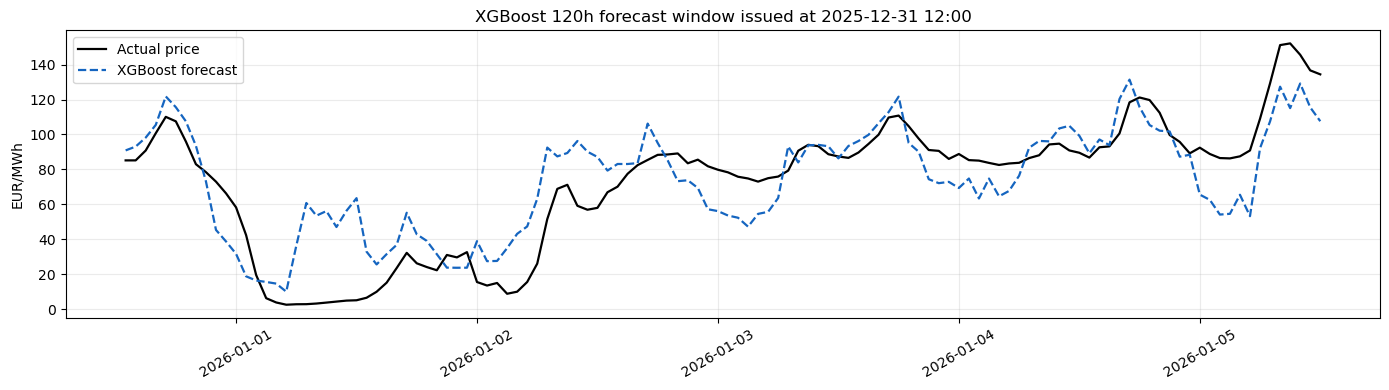

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(forecast_window["target_time"], forecast_window["DayAheadPriceEUR"], label="Actual price", color="black", linewidth=1.6)
ax.plot(forecast_window["target_time"], forecast_window["predicted"], label="XGBoost forecast", color="#1565C0", linewidth=1.6, linestyle="--")
ax.set_title(f"XGBoost 120h forecast window issued at {selected_issue_time:%Y-%m-%d %H:%M}")
ax.set_ylabel("EUR/MWh")
ax.grid(alpha=0.25)
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()


In [4]:
consumption = pd.read_csv(CONSUMPTION_PATH, parse_dates=["TimeDK"])
system_load = (
    consumption.groupby(pd.Grouper(key="TimeDK", freq="h"))["ConsumptionkWh"]
    .sum()
    .div(1000.0)
    .rename("system_load_mwh")
    .reset_index()
    .rename(columns={"TimeDK": "target_time"})
)

window_df = forecast_window.merge(system_load, on="target_time", how="left")
window_df["system_load_mwh"] = window_df["system_load_mwh"].ffill().bfill()
window_df["household_load_mwh"] = window_df["system_load_mwh"] * HOUSEHOLD_SHARE_OF_SYSTEM

display(window_df[["target_time", "horizon_h", "predicted", "DayAheadPriceEUR", "system_load_mwh", "household_load_mwh"]].head())


,target_time,horizon_h,predicted,DayAheadPriceEUR,system_load_mwh,household_load_mwh
0,2025-12-31 13:00:00,1,90.890129,85.170000,2723.044591,898.604715
1,2025-12-31 14:00:00,2,93.082664,85.177500,2614.115651,862.658165
2,2025-12-31 15:00:00,3,98.224121,90.832498,2660.063258,877.820875
3,2025-12-31 16:00:00,4,105.485001,100.705002,2788.393626,920.169897
4,2025-12-31 17:00:00,5,121.796593,110.099999,2872.311541,947.862809


In [5]:
supply = pd.read_csv(SUPPLY_PATH, parse_dates=["HourDK"])
supply = supply[supply["PriceArea"] == "DK1"].copy()

renewable_supply = (
    supply.pivot_table(
        index="HourDK",
        columns="ForecastType",
        values="ForecastDayAhead",
        aggfunc="sum",
    )
    .fillna(0.0)
)
renewable_supply["renewable_supply_proxy_mw"] = renewable_supply.sum(axis=1)
renewable_supply = renewable_supply.reset_index().rename(columns={"HourDK": "target_time"})

window_df = window_df.merge(renewable_supply[["target_time", "renewable_supply_proxy_mw"]], on="target_time", how="left")
window_df["renewable_supply_proxy_mw"] = window_df["renewable_supply_proxy_mw"].fillna(0.0)
window_df["surplus_proxy_mw"] = np.clip(window_df["renewable_supply_proxy_mw"] - window_df["system_load_mwh"], 0, None)

display(window_df[["target_time", "system_load_mwh", "renewable_supply_proxy_mw", "surplus_proxy_mw"]].head())


,target_time,system_load_mwh,renewable_supply_proxy_mw,surplus_proxy_mw
0,2025-12-31 13:00:00,2723.044591,1261.194565,0.0
1,2025-12-31 14:00:00,2614.115651,950.513336,0.0
2,2025-12-31 15:00:00,2660.063258,757.364582,0.0
3,2025-12-31 16:00:00,2788.393626,797.250000,0.0
4,2025-12-31 17:00:00,2872.311541,961.708312,0.0


In [6]:
segment_table = pd.DataFrame(SEGMENT_ASSUMPTIONS).T
segment_table.index.name = "segment"
display(segment_table)

for segment, params in SEGMENT_ASSUMPTIONS.items():
    base_col = f"{segment}_baseline_mwh"
    flex_col = f"{segment}_flexible_mwh"
    window_df[base_col] = window_df["household_load_mwh"] * params["share_of_household_load"]
    window_df[flex_col] = window_df[base_col] * params["max_shiftable_share"]

base_cols = [f"{segment}_baseline_mwh" for segment in SEGMENT_ASSUMPTIONS]
window_df["baseline_household_check_mwh"] = window_df[base_cols].sum(axis=1)
window_df[["target_time", "household_load_mwh", "baseline_household_check_mwh"]].head()


,share_of_household_load,max_shiftable_share,max_wait_h,wait_penalty
segment,,,,
inflexible,0.6,0.00,0.0,0.00
wet_loads,0.1,0.55,120.0,0.90
thermal,0.2,0.25,120.0,1.20
ev,0.1,0.85,120.0,0.35


,target_time,household_load_mwh,baseline_household_check_mwh
0,2025-12-31 13:00:00,898.604715,898.604715
1,2025-12-31 14:00:00,862.658165,862.658165
2,2025-12-31 15:00:00,877.820875,877.820875
3,2025-12-31 16:00:00,920.169897,920.169897
4,2025-12-31 17:00:00,947.862809,947.862809


In [7]:
def _normalize(series: pd.Series) -> pd.Series:
    s_min = float(series.min())
    s_max = float(series.max())
    if np.isclose(s_min, s_max):
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - s_min) / (s_max - s_min)


def build_shift_plan(window_df: pd.DataFrame, segment_assumptions: dict, decision_weights: dict):
    df = window_df.copy().reset_index(drop=True)
    df["other_system_load_mwh"] = df["system_load_mwh"] - df["household_load_mwh"]
    p95_load = max(float(df["system_load_mwh"].quantile(0.95)), 1.0)
    peak_cap = float(df["system_load_mwh"].quantile(PEAK_CAP_QUANTILE))
    max_surplus = max(float(df["surplus_proxy_mw"].max()), 1.0)
    net_shift_delta = np.zeros(len(df), dtype=float)

    shift_rows = []
    shifted_cols = []

    for segment, params in segment_assumptions.items():
        base_col = f"{segment}_baseline_mwh"
        flex_col = f"{segment}_flexible_mwh"
        shifted = df[base_col].to_numpy(dtype=float).copy()
        flexible = df[flex_col].to_numpy(dtype=float)

        if params["max_shiftable_share"] == 0 or params["max_wait_h"] == 0:
            df[f"{segment}_shifted_mwh"] = shifted
            shifted_cols.append(f"{segment}_shifted_mwh")
            continue

        for origin in range(len(df)):
            movable = flexible[origin]
            if movable <= 0:
                continue

            max_wait = int(params["max_wait_h"])
            end = min(len(df) - 1, origin + max_wait)
            candidates = df.loc[origin:end, ["target_time", "predicted", "system_load_mwh", "surplus_proxy_mw"]].copy()
            candidates["wait_h"] = np.arange(len(candidates))
            candidates["price_norm"] = _normalize(candidates["predicted"])
            candidates["wait_norm"] = candidates["wait_h"] / max(max_wait, 1)
            candidates["peak_norm"] = candidates["system_load_mwh"] / p95_load
            candidates["surplus_norm"] = candidates["surplus_proxy_mw"] / max_surplus

            candidates["score"] = (
                decision_weights["price"] * candidates["price_norm"]
                + decision_weights["wait"] * params["wait_penalty"] * candidates["wait_norm"]
                + decision_weights["peak"] * candidates["peak_norm"]
                - decision_weights["surplus"] * candidates["surplus_norm"]
            )

            origin_score = float(candidates.iloc[0]["score"])
            best_idx = int(candidates["score"].idxmin())
            best_score = float(candidates.loc[best_idx, "score"])
            score_gain = origin_score - best_score

            if best_idx == origin or score_gain < decision_weights["min_gain"]:
                continue

            projected_target_load = df.loc[best_idx, "system_load_mwh"] + net_shift_delta[best_idx] + movable
            if projected_target_load > peak_cap:
                continue

            shifted[origin] -= movable
            shifted[best_idx] += movable
            net_shift_delta[origin] -= movable
            net_shift_delta[best_idx] += movable
            shift_rows.append(
                {
                    "segment": segment,
                    "origin_index": origin,
                    "target_index": best_idx,
                    "origin_time": df.loc[origin, "target_time"],
                    "target_time": df.loc[best_idx, "target_time"],
                    "wait_h": best_idx - origin,
                    "shift_mwh": movable,
                    "origin_predicted_price": df.loc[origin, "predicted"],
                    "target_predicted_price": df.loc[best_idx, "predicted"],
                    "score_gain": score_gain,
                    "projected_target_load_mwh": projected_target_load,
                }
            )

        shifted_col = f"{segment}_shifted_mwh"
        df[shifted_col] = shifted
        shifted_cols.append(shifted_col)

    df["shifted_household_load_mwh"] = df[shifted_cols].sum(axis=1)
    df["shifted_system_load_mwh"] = df["other_system_load_mwh"] + df["shifted_household_load_mwh"]
    df["peak_cap_mwh"] = peak_cap
    df["baseline_household_cost_eur"] = df["household_load_mwh"] * df["DayAheadPriceEUR"]
    df["shifted_household_cost_eur"] = df["shifted_household_load_mwh"] * df["DayAheadPriceEUR"]
    df["baseline_predicted_cost_eur"] = df["household_load_mwh"] * df["predicted"]
    df["shifted_predicted_cost_eur"] = df["shifted_household_load_mwh"] * df["predicted"]
    df["baseline_renewable_absorption_mwh"] = np.minimum(df["household_load_mwh"], df["surplus_proxy_mw"])
    df["shifted_renewable_absorption_mwh"] = np.minimum(df["shifted_household_load_mwh"], df["surplus_proxy_mw"])

    shifts = pd.DataFrame(shift_rows)
    return df, shifts


In [8]:
prototype_df, shifts_df = build_shift_plan(window_df, SEGMENT_ASSUMPTIONS, DECISION_WEIGHTS)

summary = pd.Series(
    {
        "selected_issue_time": selected_issue_time,
        "horizon_hours": len(prototype_df),
        "n_shift_events": int(len(shifts_df)),
        "shifted_energy_mwh": float(shifts_df["shift_mwh"].sum()) if not shifts_df.empty else 0.0,
        "baseline_peak_mwh": float(prototype_df["system_load_mwh"].max()),
        "shifted_peak_mwh": float(prototype_df["shifted_system_load_mwh"].max()),
        "peak_reduction_mwh": float(prototype_df["system_load_mwh"].max() - prototype_df["shifted_system_load_mwh"].max()),
        "realized_household_savings_eur": float(prototype_df["baseline_household_cost_eur"].sum() - prototype_df["shifted_household_cost_eur"].sum()),
        "predicted_household_savings_eur": float(prototype_df["baseline_predicted_cost_eur"].sum() - prototype_df["shifted_predicted_cost_eur"].sum()),
        "extra_surplus_absorbed_mwh": float(prototype_df["shifted_renewable_absorption_mwh"].sum() - prototype_df["baseline_renewable_absorption_mwh"].sum()),
    }
)

display(summary.to_frame("value"))
display(shifts_df.sort_values("shift_mwh", ascending=False).head(20))


,value
selected_issue_time,2025-12-31 12:00:00
horizon_hours,120
n_shift_events,64
shifted_energy_mwh,3532.445669
baseline_peak_mwh,3799.688392
shifted_peak_mwh,3767.739398
peak_reduction_mwh,31.948994
realized_household_savings_eur,27653.948939
predicted_household_savings_eur,156318.035599
extra_surplus_absorbed_mwh,0.0


,segment,origin_index,target_index,origin_time,target_time,wait_h,shift_mwh,origin_predicted_price,target_predicted_price,score_gain,projected_target_load_mwh
63,ev,35,37,2026-01-02 00:00:00,2026-01-02 02:00:00,2,93.852696,38.942963,27.602230,0.098350,3217.909633
18,wet_loads,23,34,2026-01-01 12:00:00,2026-01-01 23:00:00,11,68.964344,63.552631,23.739508,0.293073,3498.711947
17,wet_loads,22,34,2026-01-01 11:00:00,2026-01-01 23:00:00,12,68.037678,56.319054,23.739508,0.241063,3429.747603
19,wet_loads,24,34,2026-01-01 13:00:00,2026-01-01 23:00:00,10,66.997853,32.916142,23.739508,0.088034,3565.709800
52,wet_loads,115,119,2026-01-05 08:00:00,2026-01-05 12:00:00,4,65.910611,127.366325,107.595734,0.634782,3700.343903
20,wet_loads,26,34,2026-01-01 15:00:00,2026-01-01 23:00:00,8,65.293915,31.518393,23.739508,0.075521,3631.003715
16,wet_loads,21,34,2026-01-01 10:00:00,2026-01-01 23:00:00,13,64.480089,47.032089,23.739508,0.165781,3361.709925
21,wet_loads,27,34,2026-01-01 16:00:00,2026-01-01 23:00:00,7,62.400666,36.819836,23.739508,0.100562,3693.404380
28,wet_loads,46,62,2026-01-02 11:00:00,2026-01-03 03:00:00,16,61.982909,90.159821,47.234329,0.379362,3080.922099
15,wet_loads,20,34,2026-01-01 09:00:00,2026-01-01 23:00:00,14,61.913139,56.167385,23.739508,0.213972,3297.229836


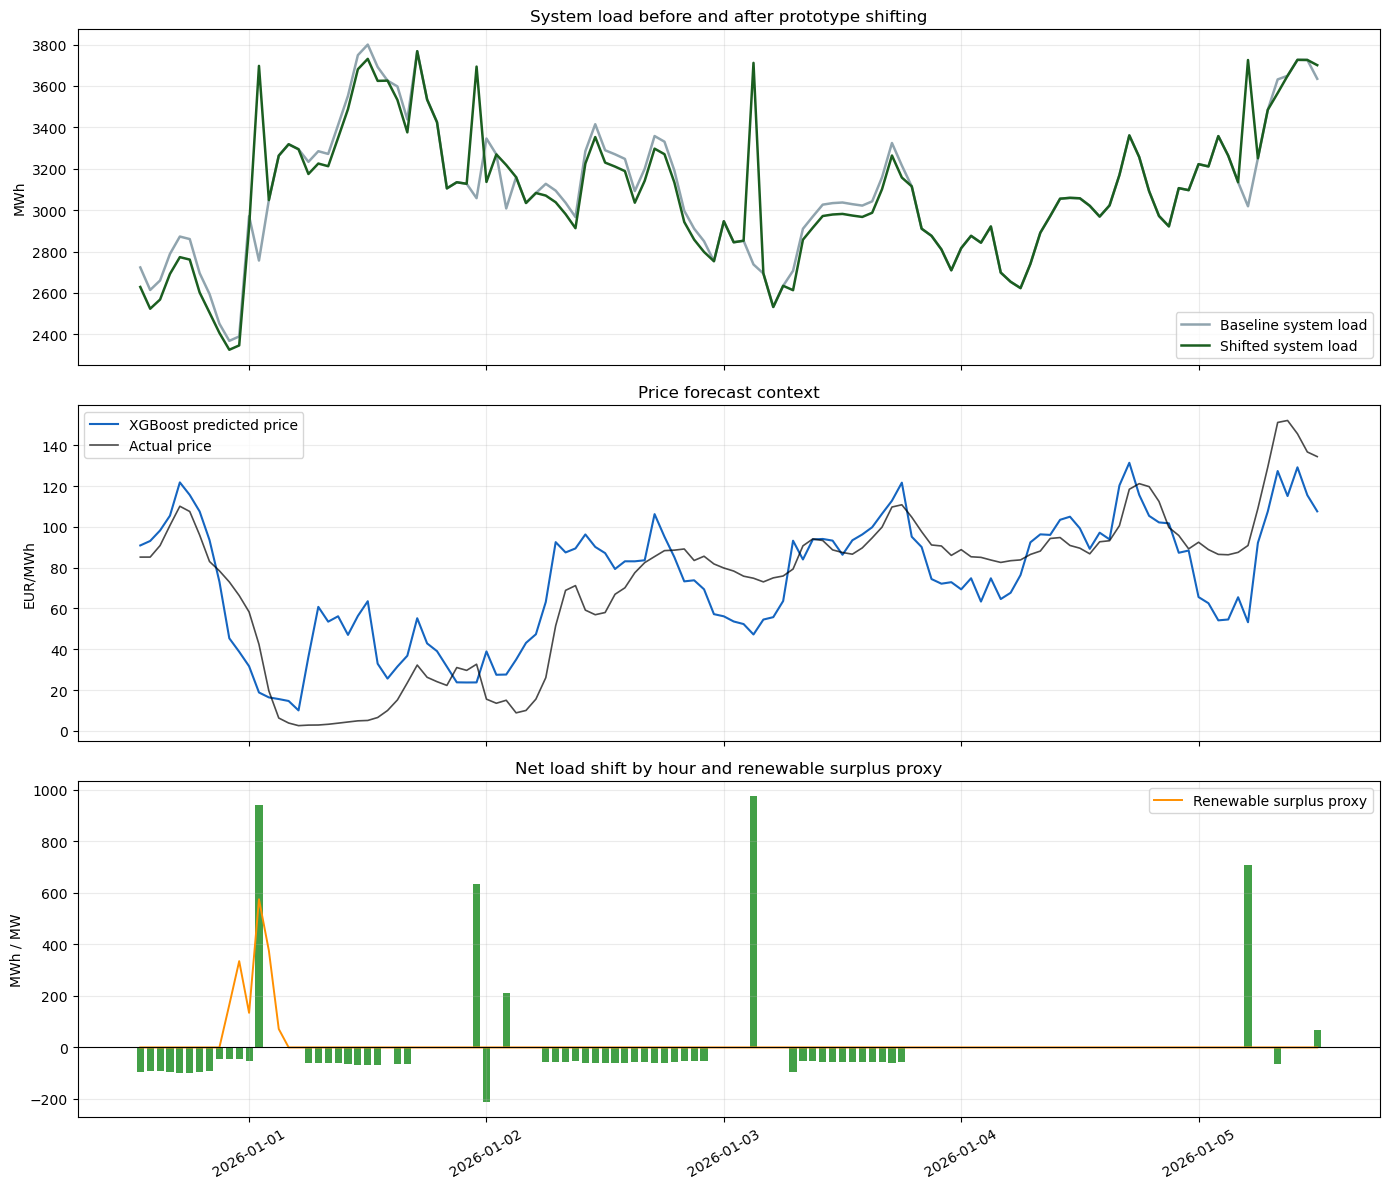

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(prototype_df["target_time"], prototype_df["system_load_mwh"], label="Baseline system load", color="#90A4AE", linewidth=1.8)
axes[0].plot(prototype_df["target_time"], prototype_df["shifted_system_load_mwh"], label="Shifted system load", color="#1B5E20", linewidth=1.8)
axes[0].set_ylabel("MWh")
axes[0].set_title("System load before and after prototype shifting")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(prototype_df["target_time"], prototype_df["predicted"], label="XGBoost predicted price", color="#1565C0", linewidth=1.5)
axes[1].plot(prototype_df["target_time"], prototype_df["DayAheadPriceEUR"], label="Actual price", color="black", linewidth=1.2, alpha=0.7)
axes[1].set_ylabel("EUR/MWh")
axes[1].set_title("Price forecast context")
axes[1].grid(alpha=0.25)
axes[1].legend()

axes[2].bar(prototype_df["target_time"], prototype_df["shifted_system_load_mwh"] - prototype_df["system_load_mwh"], width=0.03, color="#43A047")
axes[2].plot(prototype_df["target_time"], prototype_df["surplus_proxy_mw"], color="#FF8F00", linewidth=1.4, label="Renewable surplus proxy")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_ylabel("MWh / MW")
axes[2].set_title("Net load shift by hour and renewable surplus proxy")
axes[2].grid(alpha=0.25)
axes[2].legend()

plt.xticks(rotation=30)
plt.tight_layout()


## Next Prototype Steps

This first notebook version is deliberately simple. The next improvements should be:

1. move from one historical issue time to a full rolling backtest over many issue times
2. replace the heuristic with an optimization model
3. use horizon-specific XGBoost residual distributions for forecast uncertainty
4. make EV and thermal segments deadline-based instead of using one generic shift rule
5. add formal grid stress metrics and supplier-side surplus absorption metrics across the full sample
